In [1]:
# making the quadrant figures

In [28]:
import os
import pandas as pd
from scipy.stats import pearsonr, spearmanr, chisquare
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import ticker
import matplotlib
from matplotlib.patches import Circle
from itertools import combinations
import numpy as np

In [12]:
# figure save directory
save_dir = "../../img/k3-condition-quadrants"
os.makedirs(save_dir, exist_ok=True)

# input data file
input_file = '../../results/barseq/combined_grouped-barcodes_241120.csv'
df = pd.read_csv(input_file)

k3_conditions = ['VACV K3', 'K3Δ58', 'RCVZ vIF2α', 'VARV C3','MYXV M156R','TPV K3']
k3_combinations = list(combinations(k3_conditions, 2))

# Pivot the dataframe to PKR variants and mean scores for each condition
# Conditions: WT K3 versus K3Δ58
temp_df = df
temp_df = temp_df.pivot_table(index=['pkr'], columns='k3', values='auc_mean', fill_value=np.nan).reset_index()
temp_df

# Adds metadata for each PKR site and variant
temp_df = pd.merge(temp_df, df[['pkr','pkr_type','site','wt_cat','var_cat']], on='pkr', how='left')
temp_df.drop_duplicates(inplace=True)


--- VACV K3 vs VACV K3 ---
quadrant
Q3 (-x, -y)    76
Q1 (+x, +y)    18
Name: count, dtype: int64


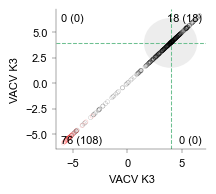


--- VACV K3 vs K3Δ58 ---
quadrant
Q3 (-x, -y)    53
Q2 (-x, +y)     2
Name: count, dtype: int64


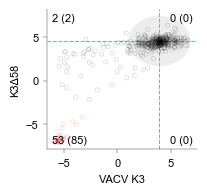


--- VACV K3 vs VARV C3 ---
quadrant
Q3 (-x, -y)    63
Q1 (+x, +y)    13
Q2 (-x, +y)     4
Name: count, dtype: int64


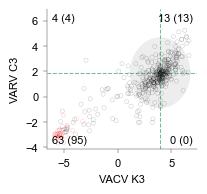


--- VACV K3 vs TPV K3 ---
quadrant
Q3 (-x, -y)    41
Q2 (-x, +y)    33
Q1 (+x, +y)    33
Name: count, dtype: int64


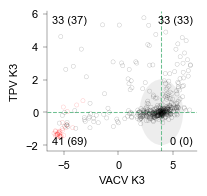


--- VACV K3 vs MYXV M156R ---
quadrant
Q3 (-x, -y)    57
Q4 (+x, -y)     6
Q2 (-x, +y)     4
Name: count, dtype: int64


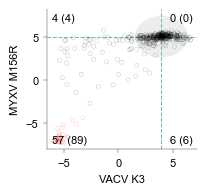


--- VACV K3 vs RCVZ vIF2α ---
quadrant
Q3 (-x, -y)    55
Q2 (-x, +y)    49
Q1 (+x, +y)    46
Q4 (+x, -y)    15
Name: count, dtype: int64


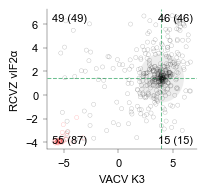

In [30]:
x_k3_cond = 'VACV K3'
k3d58_cond = 'K3Δ58'
k3d58_threshold = -3

k3_cond_list = ['VACV K3','K3Δ58', 'VARV C3', 'TPV K3', 'MYXV M156R', 'RCVZ vIF2α']

def get_std_wt_pkr(k3_condition, pkr_condition):
    """Returns the standard deviation of PKR-WT for a given K3 condition from the main df"""
    condition1 = df['k3'] == k3_condition
    condition2 = df['pkr'] == pkr_condition
    return df[condition1 & condition2]['auc_std'].iloc[0]

# get WT x center and std (constant across iterations)
wt_row = temp_df.query('pkr == "PKR-WT"')
wt_x_center = wt_row[x_k3_cond].iloc[0]
wt_x_std = get_std_wt_pkr(x_k3_cond, "PKR-WT")

# split functional/nonfunctional once (constant across iterations)
functional_mask = temp_df[k3d58_cond] >= k3d58_threshold
df_functional = temp_df[functional_mask]
df_nonfunctional = temp_df[~functional_mask]

for y_k3_cond in k3_cond_list:

    # get WT y center and exclusion radius
    wt_y_center = wt_row[y_k3_cond].iloc[0]
    wt_y_std = get_std_wt_pkr(y_k3_cond, "PKR-WT")
    exclusion_radius = 2 * np.mean([wt_x_std, wt_y_std])

    # filter: outside exclusion radius and K3Δ58 >= threshold
    r = np.sqrt((temp_df[x_k3_cond] - wt_x_center)**2 + (temp_df[y_k3_cond] - wt_y_center)**2)
    outside_mask = r > exclusion_radius
    df_outside = temp_df[outside_mask & functional_mask].copy()

    # quadrant assignment (functional only)
    x_out = df_outside[x_k3_cond]
    y_out = df_outside[y_k3_cond]
    quadrant_conditions = {
        "Q1 (+x, +y)": (x_out >= wt_x_center) & (y_out >= wt_y_center),
        "Q2 (-x, +y)": (x_out <  wt_x_center) & (y_out >= wt_y_center),
        "Q3 (-x, -y)": (x_out <  wt_x_center) & (y_out <  wt_y_center),
        "Q4 (+x, -y)": (x_out >= wt_x_center) & (y_out <  wt_y_center),
    }
    df_outside["quadrant"] = np.select(
        list(quadrant_conditions.values()),
        list(quadrant_conditions.keys()),
        default=None
    )
    q_counts_func = df_outside['quadrant'].value_counts()

    # quadrant assignment (all points, including nonfunctional)
    df_outside_all = temp_df[outside_mask].copy()
    x_out_all = df_outside_all[x_k3_cond]
    y_out_all = df_outside_all[y_k3_cond]
    quadrant_conditions_all = {
        "Q1 (+x, +y)": (x_out_all >= wt_x_center) & (y_out_all >= wt_y_center),
        "Q2 (-x, +y)": (x_out_all <  wt_x_center) & (y_out_all >= wt_y_center),
        "Q3 (-x, -y)": (x_out_all <  wt_x_center) & (y_out_all <  wt_y_center),
        "Q4 (+x, -y)": (x_out_all >= wt_x_center) & (y_out_all <  wt_y_center),
    }
    df_outside_all["quadrant"] = np.select(
        list(quadrant_conditions_all.values()),
        list(quadrant_conditions_all.keys()),
        default=None
    )
    q_counts_all = df_outside_all['quadrant'].value_counts()

    print(f"\n--- {x_k3_cond} vs {y_k3_cond} ---")
    print(df_outside['quadrant'].value_counts())

    # --- scatterplot ---
    width_in = 2
    height_in = 2
    font_size = 8
    font_name = 'Arial'
    stroke = 0.25
    tick_len = 3
    alpha_val = 0.3
    marker_size = 3
    edge_line_width = .25
    crosshair_color = '#6dc091'
    crosshair_stroke = .75

    fig, ax = plt.subplots(figsize=(width_in, height_in))

    # exclusion radius circle (filled light gray, no outline)
    circle = plt.Circle((wt_x_center, wt_y_center), exclusion_radius,
                         color='gainsboro', fill=True, linewidth=0, zorder=1, alpha=.5)
    ax.add_patch(circle)

    # WT center crosshairs
    ax.axvline(wt_x_center, color=crosshair_color, linewidth=crosshair_stroke, linestyle='--', zorder=2)
    ax.axhline(wt_y_center, color=crosshair_color, linewidth=crosshair_stroke, linestyle='--', zorder=2)

    # scatter: functional (black edges) and nonfunctional (red edges), no fill
    ax.scatter(df_functional[x_k3_cond], df_functional[y_k3_cond],
               facecolors='none', edgecolors='black', linewidths=edge_line_width,
               s=marker_size**2, alpha=alpha_val, zorder=3, label='Functional')
    ax.scatter(df_nonfunctional[x_k3_cond], df_nonfunctional[y_k3_cond],
               facecolors='none', edgecolors='red', linewidths=edge_line_width,
               s=marker_size**2, alpha=alpha_val, zorder=3, label=f'{k3d58_cond} < {k3d58_threshold}')

    # quadrant counts: functional (all) in each corner
    q_text = {
        "Q1 (+x, +y)": (0.97, 0.97, 'right', 'top'),
        "Q2 (-x, +y)": (0.03, 0.97, 'left',  'top'),
        "Q3 (-x, -y)": (0.03, 0.03, 'left',  'bottom'),
        "Q4 (+x, -y)": (0.97, 0.03, 'right', 'bottom'),
    }
    for q, (x_pos, y_pos, ha, va) in q_text.items():
        count_func = q_counts_func.get(q, 0)
        count_all  = q_counts_all.get(q, 0)
        ax.text(x_pos, y_pos, f"{count_func} ({count_all})", transform=ax.transAxes,
                fontsize=font_size, fontname=font_name, ha=ha, va=va, color='black')

    ax.set_xlabel(x_k3_cond, fontsize=font_size, fontname=font_name)
    ax.set_ylabel(y_k3_cond, fontsize=font_size, fontname=font_name)

    # remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(stroke)
    ax.spines['bottom'].set_linewidth(stroke)

    ax.tick_params(labelsize=font_size, length=tick_len, width=stroke)
    for spine in ax.spines.values():
        spine.set_linewidth(stroke)

    fig.subplots_adjust(left=0.2, right=0.95, top=0.9, bottom=0.2)

    plot_name = f'quad-scatter_{x_k3_cond}_{y_k3_cond}.svg'
    output_file = os.path.join(save_dir, plot_name)
    plt.savefig(output_file, bbox_inches='tight', format='svg', transparent=True)
    plt.show()


--- VACV K3 vs K3Δ58 ---
quadrant
Q3 (-x, -y)    53
Q2 (-x, +y)     2
Name: count, dtype: int64
Chi-square: 149.582, p-value: 0.0000


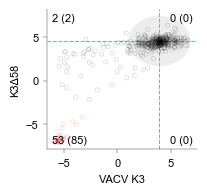


--- VACV K3 vs VARV C3 ---
quadrant
Q3 (-x, -y)    63
Q1 (+x, +y)    13
Q2 (-x, +y)     4
Name: count, dtype: int64
Chi-square: 127.700, p-value: 0.0000


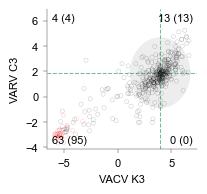


--- VACV K3 vs TPV K3 ---
quadrant
Q3 (-x, -y)    41
Q2 (-x, +y)    33
Q1 (+x, +y)    33
Name: count, dtype: int64
Chi-square: 37.262, p-value: 0.0000


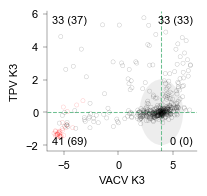


--- VACV K3 vs MYXV M156R ---
quadrant
Q3 (-x, -y)    57
Q4 (+x, -y)     6
Q2 (-x, +y)     4
Name: count, dtype: int64
Chi-square: 130.075, p-value: 0.0000


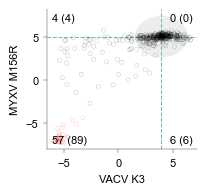


--- VACV K3 vs RCVZ vIF2α ---
quadrant
Q3 (-x, -y)    55
Q2 (-x, +y)    49
Q1 (+x, +y)    46
Q4 (+x, -y)    15
Name: count, dtype: int64
Chi-square: 23.291, p-value: 0.0000


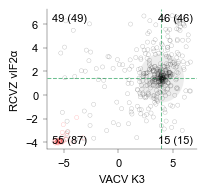

In [29]:
x_k3_cond = 'VACV K3'
k3d58_cond = 'K3Δ58'
k3d58_threshold = -3

k3_cond_list = ['K3Δ58', 'VARV C3', 'TPV K3', 'MYXV M156R', 'RCVZ vIF2α']

def get_std_wt_pkr(k3_condition, pkr_condition):
    """Returns the standard deviation of PKR-WT for a given K3 condition from the main df"""
    condition1 = df['k3'] == k3_condition
    condition2 = df['pkr'] == pkr_condition
    return df[condition1 & condition2]['auc_std'].iloc[0]

# get WT x center and std (constant across iterations)
wt_row = temp_df.query('pkr == "PKR-WT"')
wt_x_center = wt_row[x_k3_cond].iloc[0]
wt_x_std = get_std_wt_pkr(x_k3_cond, "PKR-WT")

# split functional/nonfunctional once (constant across iterations)
functional_mask = temp_df[k3d58_cond] >= k3d58_threshold
df_functional = temp_df[functional_mask]
df_nonfunctional = temp_df[~functional_mask]

for y_k3_cond in k3_cond_list:

    # get WT y center and exclusion radius
    wt_y_center = wt_row[y_k3_cond].iloc[0]
    wt_y_std = get_std_wt_pkr(y_k3_cond, "PKR-WT")
    exclusion_radius = 2 * np.mean([wt_x_std, wt_y_std])

    # filter: outside exclusion radius and K3Δ58 >= threshold
    r = np.sqrt((temp_df[x_k3_cond] - wt_x_center)**2 + (temp_df[y_k3_cond] - wt_y_center)**2)
    outside_mask = r > exclusion_radius
    df_outside = temp_df[outside_mask & functional_mask].copy()

    # quadrant assignment (functional only)
    x_out = df_outside[x_k3_cond]
    y_out = df_outside[y_k3_cond]
    quadrant_conditions = {
        "Q1 (+x, +y)": (x_out >= wt_x_center) & (y_out >= wt_y_center),
        "Q2 (-x, +y)": (x_out <  wt_x_center) & (y_out >= wt_y_center),
        "Q3 (-x, -y)": (x_out <  wt_x_center) & (y_out <  wt_y_center),
        "Q4 (+x, -y)": (x_out >= wt_x_center) & (y_out <  wt_y_center),
    }
    df_outside["quadrant"] = np.select(
        list(quadrant_conditions.values()),
        list(quadrant_conditions.keys()),
        default=None
    )
    q_counts_func = df_outside['quadrant'].value_counts()

    # quadrant assignment (all points, including nonfunctional)
    df_outside_all = temp_df[outside_mask].copy()
    x_out_all = df_outside_all[x_k3_cond]
    y_out_all = df_outside_all[y_k3_cond]
    quadrant_conditions_all = {
        "Q1 (+x, +y)": (x_out_all >= wt_x_center) & (y_out_all >= wt_y_center),
        "Q2 (-x, +y)": (x_out_all <  wt_x_center) & (y_out_all >= wt_y_center),
        "Q3 (-x, -y)": (x_out_all <  wt_x_center) & (y_out_all <  wt_y_center),
        "Q4 (+x, -y)": (x_out_all >= wt_x_center) & (y_out_all <  wt_y_center),
    }
    df_outside_all["quadrant"] = np.select(
        list(quadrant_conditions_all.values()),
        list(quadrant_conditions_all.keys()),
        default=None
    )
    q_counts_all = df_outside_all['quadrant'].value_counts()

    # chi-square test on functional quadrant counts
    observed = np.array([q_counts_func.get(q, 0) for q in quadrant_conditions.keys()])
    expected = np.full(4, observed.sum() / 4)  # equal distribution across quadrants
    chi2, p_val = chisquare(f_obs=observed, f_exp=expected)

    print(f"\n--- {x_k3_cond} vs {y_k3_cond} ---")
    print(df_outside['quadrant'].value_counts())
    print(f"Chi-square: {chi2:.3f}, p-value: {p_val:.4f}")

    # --- scatterplot ---
    width_in = 2
    height_in = 2
    font_size = 8
    font_name = 'Arial'
    stroke = 0.25
    tick_len = 3
    alpha_val = 0.3
    marker_size = 3
    edge_line_width = .25
    crosshair_color = '#6dc091'
    crosshair_stroke = .75

    fig, ax = plt.subplots(figsize=(width_in, height_in))

    # exclusion radius circle (filled light gray, no outline)
    circle = plt.Circle((wt_x_center, wt_y_center), exclusion_radius,
                         color='gainsboro', fill=True, linewidth=0, zorder=1, alpha=.5)
    ax.add_patch(circle)

    # WT center crosshairs
    ax.axvline(wt_x_center, color=crosshair_color, linewidth=crosshair_stroke, linestyle='--', zorder=2)
    ax.axhline(wt_y_center, color=crosshair_color, linewidth=crosshair_stroke, linestyle='--', zorder=2)

    # scatter: functional (black edges) and nonfunctional (red edges), no fill
    ax.scatter(df_functional[x_k3_cond], df_functional[y_k3_cond],
               facecolors='none', edgecolors='black', linewidths=edge_line_width,
               s=marker_size**2, alpha=alpha_val, zorder=3, label='Functional')
    ax.scatter(df_nonfunctional[x_k3_cond], df_nonfunctional[y_k3_cond],
               facecolors='none', edgecolors='red', linewidths=edge_line_width,
               s=marker_size**2, alpha=alpha_val, zorder=3, label=f'{k3d58_cond} < {k3d58_threshold}')

    # quadrant counts: functional (all) in each corner
    q_text = {
        "Q1 (+x, +y)": (0.97, 0.97, 'right', 'top'),
        "Q2 (-x, +y)": (0.03, 0.97, 'left',  'top'),
        "Q3 (-x, -y)": (0.03, 0.03, 'left',  'bottom'),
        "Q4 (+x, -y)": (0.97, 0.03, 'right', 'bottom'),
    }
    for q, (x_pos, y_pos, ha, va) in q_text.items():
        count_func = q_counts_func.get(q, 0)
        count_all  = q_counts_all.get(q, 0)
        ax.text(x_pos, y_pos, f"{count_func} ({count_all})", transform=ax.transAxes,
                fontsize=font_size, fontname=font_name, ha=ha, va=va, color='black')

    ax.set_xlabel(x_k3_cond, fontsize=font_size, fontname=font_name)
    ax.set_ylabel(y_k3_cond, fontsize=font_size, fontname=font_name)

    # remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(stroke)
    ax.spines['bottom'].set_linewidth(stroke)

    ax.tick_params(labelsize=font_size, length=tick_len, width=stroke)
    for spine in ax.spines.values():
        spine.set_linewidth(stroke)

    fig.subplots_adjust(left=0.2, right=0.95, top=0.9, bottom=0.2)

    plot_name = f'quad-scatter_{x_k3_cond}_{y_k3_cond}.svg'
    output_file = os.path.join(save_dir, plot_name)
    #plt.savefig(output_file, bbox_inches='tight', format='svg', transparent=True)
    plt.show()


--- VACV K3 vs K3Δ58 ---
quadrant
Q3 (-x, -y)    53
Q2 (-x, +y)     2
Name: count, dtype: int64


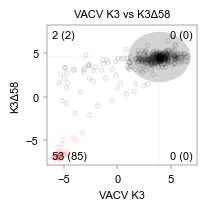


--- VACV K3 vs VARV C3 ---
quadrant
Q3 (-x, -y)    63
Q1 (+x, +y)    13
Q2 (-x, +y)     4
Name: count, dtype: int64


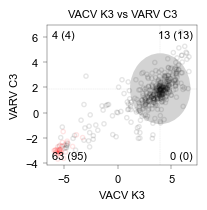


--- VACV K3 vs TPV K3 ---
quadrant
Q3 (-x, -y)    41
Q2 (-x, +y)    33
Q1 (+x, +y)    33
Name: count, dtype: int64


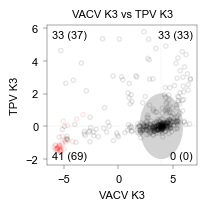


--- VACV K3 vs MYXV M156R ---
quadrant
Q3 (-x, -y)    57
Q4 (+x, -y)     6
Q2 (-x, +y)     4
Name: count, dtype: int64


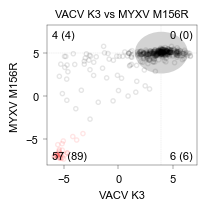


--- VACV K3 vs RCVZ vIF2α ---
quadrant
Q3 (-x, -y)    55
Q2 (-x, +y)    49
Q1 (+x, +y)    46
Q4 (+x, -y)    15
Name: count, dtype: int64


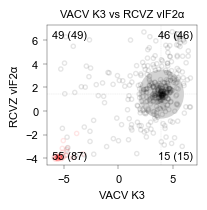

In [25]:
x_k3_cond = 'VACV K3'
k3d58_cond = 'K3Δ58'
k3d58_threshold = -3

k3_cond_list = ['K3Δ58', 'VARV C3', 'TPV K3', 'MYXV M156R', 'RCVZ vIF2α']

def get_std_wt_pkr(k3_condition, pkr_condition):
    """Returns the standard deviation of PKR-WT for a given K3 condition from the main df"""
    condition1 = df['k3'] == k3_condition
    condition2 = df['pkr'] == pkr_condition
    return df[condition1 & condition2]['auc_std'].iloc[0]

# get WT x center and std (constant across iterations)
wt_row = temp_df.query('pkr == "PKR-WT"')
wt_x_center = wt_row[x_k3_cond].iloc[0]
wt_x_std = get_std_wt_pkr(x_k3_cond, "PKR-WT")

# split functional/nonfunctional once (constant across iterations)
functional_mask = temp_df[k3d58_cond] >= k3d58_threshold
df_functional = temp_df[functional_mask]
df_nonfunctional = temp_df[~functional_mask]

for y_k3_cond in k3_cond_list:

    # get WT y center and exclusion radius
    wt_y_center = wt_row[y_k3_cond].iloc[0]
    wt_y_std = get_std_wt_pkr(y_k3_cond, "PKR-WT")
    exclusion_radius = 2 * np.mean([wt_x_std, wt_y_std])

    # filter: outside exclusion radius and K3Δ58 >= threshold
    r = np.sqrt((temp_df[x_k3_cond] - wt_x_center)**2 + (temp_df[y_k3_cond] - wt_y_center)**2)
    outside_mask = r > exclusion_radius
    df_outside = temp_df[outside_mask & functional_mask].copy()

    # quadrant assignment
    x_out = df_outside[x_k3_cond]
    y_out = df_outside[y_k3_cond]

    quadrant_conditions = {
        "Q1 (+x, +y)": (x_out >= wt_x_center) & (y_out >= wt_y_center),
        "Q2 (-x, +y)": (x_out <  wt_x_center) & (y_out >= wt_y_center),
        "Q3 (-x, -y)": (x_out <  wt_x_center) & (y_out <  wt_y_center),
        "Q4 (+x, -y)": (x_out >= wt_x_center) & (y_out <  wt_y_center),
    }

    df_outside["quadrant"] = np.select(
        list(quadrant_conditions.values()),
        list(quadrant_conditions.keys()),
        default=None
    )

    print(f"\n--- {x_k3_cond} vs {y_k3_cond} ---")
    print(df_outside['quadrant'].value_counts())

    # --- scatterplot ---
    width_in = 2
    height_in = 2
    font_size = 8
    font_name = 'Arial'
    stroke = 0.25
    tick_len = 3
    alpha_val = 0.1
    marker_size = 3
    edge_line_width = 1
    crosshair_color = '#d9d9d9'

    fig, ax = plt.subplots(figsize=(width_in, height_in))

    # exclusion radius circle (filled light gray, no outline)
    circle = plt.Circle((wt_x_center, wt_y_center), exclusion_radius,
                         color='lightgray', fill=True, linewidth=0, zorder=1)
    ax.add_patch(circle)

    # WT center crosshairs
    ax.axvline(wt_x_center, color=crosshair_color, linewidth=stroke, linestyle='--', zorder=2)
    ax.axhline(wt_y_center, color=crosshair_color, linewidth=stroke, linestyle='--', zorder=2)

    # scatter: functional (black edges) and nonfunctional (red edges), no fill
    ax.scatter(df_functional[x_k3_cond], df_functional[y_k3_cond],
               facecolors='none', edgecolors='black', linewidths=edge_line_width,
               s=marker_size**2, alpha=alpha_val, zorder=3, label='Functional')
    ax.scatter(df_nonfunctional[x_k3_cond], df_nonfunctional[y_k3_cond],
               facecolors='none', edgecolors='red', linewidths=edge_line_width,
               s=marker_size**2, alpha=alpha_val, zorder=3, label=f'{k3d58_cond} < {k3d58_threshold}')

    ax.set_xlabel(x_k3_cond, fontsize=font_size, fontname=font_name)
    ax.set_ylabel(y_k3_cond, fontsize=font_size, fontname=font_name)
    ax.set_title(f'{x_k3_cond} vs {y_k3_cond}', fontsize=font_size, fontname=font_name)

    ax.tick_params(labelsize=font_size, length=tick_len, width=stroke)
    for spine in ax.spines.values():
        spine.set_linewidth(stroke)

    # quadrant counts: all points (including nonfunctional) and functional only
    # assign quadrants for all points outside exclusion radius (no k3d58 filter)
    df_outside_all = temp_df[outside_mask].copy()
    x_out_all = df_outside_all[x_k3_cond]
    y_out_all = df_outside_all[y_k3_cond]
    quadrant_conditions_all = {
        "Q1 (+x, +y)": (x_out_all >= wt_x_center) & (y_out_all >= wt_y_center),
        "Q2 (-x, +y)": (x_out_all <  wt_x_center) & (y_out_all >= wt_y_center),
        "Q3 (-x, -y)": (x_out_all <  wt_x_center) & (y_out_all <  wt_y_center),
        "Q4 (+x, -y)": (x_out_all >= wt_x_center) & (y_out_all <  wt_y_center),
    }
    df_outside_all["quadrant"] = np.select(
        list(quadrant_conditions_all.values()),
        list(quadrant_conditions_all.keys()),
        default=None
    )
    q_counts_all = df_outside_all['quadrant'].value_counts()
    q_counts_func = df_outside['quadrant'].value_counts()

    q_text = {
        "Q1 (+x, +y)": (0.97, 0.97, 'right', 'top'),
        "Q2 (-x, +y)": (0.03, 0.97, 'left',  'top'),
        "Q3 (-x, -y)": (0.03, 0.03, 'left',  'bottom'),
        "Q4 (+x, -y)": (0.97, 0.03, 'right', 'bottom'),
    }
    for q, (x_pos, y_pos, ha, va) in q_text.items():
        count_all  = q_counts_all.get(q, 0)
        count_func = q_counts_func.get(q, 0)
        ax.text(x_pos, y_pos, f"{count_func} ({count_all})", transform=ax.transAxes,
                fontsize=font_size, fontname=font_name,
                ha=ha, va=va, color='black')

    fig.subplots_adjust(left=0.2, right=0.95, top=0.9, bottom=0.2)
    plt.show()


--- VACV K3 vs K3Δ58 ---
quadrant
Q3 (-x, -y)    53
Q2 (-x, +y)     2
Name: count, dtype: int64


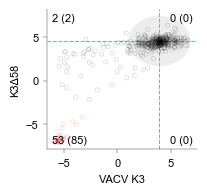


--- VACV K3 vs VARV C3 ---
quadrant
Q3 (-x, -y)    63
Q1 (+x, +y)    13
Q2 (-x, +y)     4
Name: count, dtype: int64


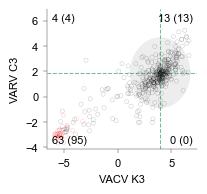


--- VACV K3 vs TPV K3 ---
quadrant
Q3 (-x, -y)    41
Q2 (-x, +y)    33
Q1 (+x, +y)    33
Name: count, dtype: int64


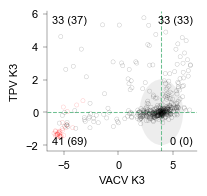


--- VACV K3 vs MYXV M156R ---
quadrant
Q3 (-x, -y)    57
Q4 (+x, -y)     6
Q2 (-x, +y)     4
Name: count, dtype: int64


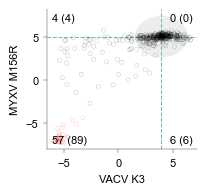


--- VACV K3 vs RCVZ vIF2α ---
quadrant
Q3 (-x, -y)    55
Q2 (-x, +y)    49
Q1 (+x, +y)    46
Q4 (+x, -y)    15
Name: count, dtype: int64


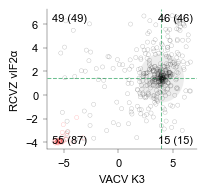

In [26]:
x_k3_cond = 'VACV K3'
k3d58_cond = 'K3Δ58'
k3d58_threshold = -3

k3_cond_list = ['K3Δ58', 'VARV C3', 'TPV K3', 'MYXV M156R', 'RCVZ vIF2α']

def get_std_wt_pkr(k3_condition, pkr_condition):
    """Returns the standard deviation of PKR-WT for a given K3 condition from the main df"""
    condition1 = df['k3'] == k3_condition
    condition2 = df['pkr'] == pkr_condition
    return df[condition1 & condition2]['auc_std'].iloc[0]

# get WT x center and std (constant across iterations)
wt_row = temp_df.query('pkr == "PKR-WT"')
wt_x_center = wt_row[x_k3_cond].iloc[0]
wt_x_std = get_std_wt_pkr(x_k3_cond, "PKR-WT")

# split functional/nonfunctional once (constant across iterations)
functional_mask = temp_df[k3d58_cond] >= k3d58_threshold
df_functional = temp_df[functional_mask]
df_nonfunctional = temp_df[~functional_mask]

for y_k3_cond in k3_cond_list:

    # get WT y center and exclusion radius
    wt_y_center = wt_row[y_k3_cond].iloc[0]
    wt_y_std = get_std_wt_pkr(y_k3_cond, "PKR-WT")
    exclusion_radius = 2 * np.mean([wt_x_std, wt_y_std])

    # filter: outside exclusion radius and K3Δ58 >= threshold
    r = np.sqrt((temp_df[x_k3_cond] - wt_x_center)**2 + (temp_df[y_k3_cond] - wt_y_center)**2)
    outside_mask = r > exclusion_radius
    df_outside = temp_df[outside_mask & functional_mask].copy()

    # quadrant assignment (functional only)
    x_out = df_outside[x_k3_cond]
    y_out = df_outside[y_k3_cond]
    quadrant_conditions = {
        "Q1 (+x, +y)": (x_out >= wt_x_center) & (y_out >= wt_y_center),
        "Q2 (-x, +y)": (x_out <  wt_x_center) & (y_out >= wt_y_center),
        "Q3 (-x, -y)": (x_out <  wt_x_center) & (y_out <  wt_y_center),
        "Q4 (+x, -y)": (x_out >= wt_x_center) & (y_out <  wt_y_center),
    }
    df_outside["quadrant"] = np.select(
        list(quadrant_conditions.values()),
        list(quadrant_conditions.keys()),
        default=None
    )
    q_counts_func = df_outside['quadrant'].value_counts()

    # quadrant assignment (all points, including nonfunctional)
    df_outside_all = temp_df[outside_mask].copy()
    x_out_all = df_outside_all[x_k3_cond]
    y_out_all = df_outside_all[y_k3_cond]
    quadrant_conditions_all = {
        "Q1 (+x, +y)": (x_out_all >= wt_x_center) & (y_out_all >= wt_y_center),
        "Q2 (-x, +y)": (x_out_all <  wt_x_center) & (y_out_all >= wt_y_center),
        "Q3 (-x, -y)": (x_out_all <  wt_x_center) & (y_out_all <  wt_y_center),
        "Q4 (+x, -y)": (x_out_all >= wt_x_center) & (y_out_all <  wt_y_center),
    }
    df_outside_all["quadrant"] = np.select(
        list(quadrant_conditions_all.values()),
        list(quadrant_conditions_all.keys()),
        default=None
    )
    q_counts_all = df_outside_all['quadrant'].value_counts()

    print(f"\n--- {x_k3_cond} vs {y_k3_cond} ---")
    print(df_outside['quadrant'].value_counts())

    # --- scatterplot ---
    width_in = 2
    height_in = 2
    font_size = 8
    font_name = 'Arial'
    stroke = 0.25
    tick_len = 3
    alpha_val = 0.3
    marker_size = 3
    edge_line_width = .25
    crosshair_color = '#6dc091'
    crosshair_stroke = .75

    fig, ax = plt.subplots(figsize=(width_in, height_in))

    # exclusion radius circle (filled light gray, no outline)
    circle = plt.Circle((wt_x_center, wt_y_center), exclusion_radius,
                         color='gainsboro', fill=True, linewidth=0, zorder=1, alpha=.5)
    ax.add_patch(circle)

    # WT center crosshairs
    ax.axvline(wt_x_center, color=crosshair_color, linewidth=crosshair_stroke, linestyle='--', zorder=2)
    ax.axhline(wt_y_center, color=crosshair_color, linewidth=crosshair_stroke, linestyle='--', zorder=2)

    # scatter: functional (black edges) and nonfunctional (red edges), no fill
    ax.scatter(df_functional[x_k3_cond], df_functional[y_k3_cond],
               facecolors='none', edgecolors='black', linewidths=edge_line_width,
               s=marker_size**2, alpha=alpha_val, zorder=3, label='Functional')
    ax.scatter(df_nonfunctional[x_k3_cond], df_nonfunctional[y_k3_cond],
               facecolors='none', edgecolors='red', linewidths=edge_line_width,
               s=marker_size**2, alpha=alpha_val, zorder=3, label=f'{k3d58_cond} < {k3d58_threshold}')

    # quadrant counts: functional (all) in each corner
    q_text = {
        "Q1 (+x, +y)": (0.97, 0.97, 'right', 'top'),
        "Q2 (-x, +y)": (0.03, 0.97, 'left',  'top'),
        "Q3 (-x, -y)": (0.03, 0.03, 'left',  'bottom'),
        "Q4 (+x, -y)": (0.97, 0.03, 'right', 'bottom'),
    }
    for q, (x_pos, y_pos, ha, va) in q_text.items():
        count_func = q_counts_func.get(q, 0)
        count_all  = q_counts_all.get(q, 0)
        ax.text(x_pos, y_pos, f"{count_func} ({count_all})", transform=ax.transAxes,
                fontsize=font_size, fontname=font_name, ha=ha, va=va, color='black')

    ax.set_xlabel(x_k3_cond, fontsize=font_size, fontname=font_name)
    ax.set_ylabel(y_k3_cond, fontsize=font_size, fontname=font_name)

    # remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(stroke)
    ax.spines['bottom'].set_linewidth(stroke)

    ax.tick_params(labelsize=font_size, length=tick_len, width=stroke)
    for spine in ax.spines.values():
        spine.set_linewidth(stroke)

    fig.subplots_adjust(left=0.2, right=0.95, top=0.9, bottom=0.2)

    plot_name = f'quad-scatter_{x_k3_cond}_{y_k3_cond}.svg'
    output_file = os.path.join(save_dir, plot_name)
    plt.savefig(output_file, bbox_inches='tight', format='svg', transparent=True)
    plt.show()